<a href="https://colab.research.google.com/github/Shamsfathalla/FlyRank-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Shamsfathalla/FlyRank-Starter-Notebooks/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This playbook translates the model's scores into clear tasks. It ranks pages from highest missed opportunity to lowest.

Action: REVIEW_TITLE. Reason: PAGE_ONE_ZERO_CLICKS (Ranks on page 1 but gets no clicks).

Action: REVIEW_INTENT. Reason: HIGH_VOL_LOW_CTR (Gets impressions but low engagement).

Action: MONITOR. Reason: NORMAL (Performing as expected).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import duckdb
import pandas as pd
from google.colab import userdata

# Setup connection
hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
table = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

df = con.sql(f"""
    SELECT content_hash_id, gsc_impressions, gsc_clicks, gsc_avg_position
    FROM {table}
    WHERE month = '2026-03' AND gsc_impressions > 50 LIMIT 10000
""").df()

df['target'] = ((df['gsc_impressions'] > 50) & (df['gsc_clicks'] == 0)).astype(int)
rf = RandomForestClassifier(max_depth=3, random_state=42)
rf.fit(df[['gsc_impressions', 'gsc_avg_position']], df['target'])

df['score'] = rf.predict_proba(df[['gsc_impressions', 'gsc_avg_position']])[:, 1]

def get_action(row):
    if row['score'] > 0.6 and row['gsc_avg_position'] <= 10:
        return pd.Series(['REVIEW_TITLE', 'PAGE_ONE_ZERO_CLICKS'])
    elif row['score'] > 0.4:
        return pd.Series(['REVIEW_INTENT', 'HIGH_VOL_LOW_CTR'])
    return pd.Series(['MONITOR', 'NORMAL'])

df[['action', 'reason']] = df.apply(get_action, axis=1)
queue = df.sort_values(by='score', ascending=False)

print(queue[['content_hash_id', 'score', 'action', 'reason']].head(5))

               content_hash_id     score        action                reason
8645  content_202bce1967a1c47c  0.938129  REVIEW_TITLE  PAGE_ONE_ZERO_CLICKS
8646  content_7cce1f4865bc2b23  0.938129  REVIEW_TITLE  PAGE_ONE_ZERO_CLICKS
8647  content_3cf66f4733be8842  0.938129  REVIEW_TITLE  PAGE_ONE_ZERO_CLICKS
8648  content_957c82ba473901e9  0.938129  REVIEW_TITLE  PAGE_ONE_ZERO_CLICKS
8649  content_f55d585fcc15cf29  0.938129  REVIEW_TITLE  PAGE_ONE_ZERO_CLICKS


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Who uses this: SEO editors and content managers.
For what: To prioritize which pages to update first each week.
Limits: The model only reads numbers. It does not read the actual article text or know the searcher's true intent. It points to symptoms, not guaranteed cures.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Action counts for this batch:")
print(queue['action'].value_counts())

Action counts for this batch:
action
REVIEW_TITLE     5599
REVIEW_INTENT    3451
MONITOR           950
Name: count, dtype: int64


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human review: An editor must check live Google search results before changing a page to see what competitors are doing.
No-go list (Never automate):

Never automatically rewrite page titles based on this score.

Never bulk-delete or redirect pages. Human judgment is required for destructive actions.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
manual_reviews = len(queue[queue['action'] != 'MONITOR'])
print(f"Pages requiring manual human review: {manual_reviews}")

Pages requiring manual human review: 9050


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Recommendations go stale if search behavior changes.

Retrain trigger: If editors reject or ignore more than 50% of the recommended REVIEW actions in a month.

Data drift: If the model's ROC-AUC drops significantly on new monthly data, it means Google's ranking patterns shifted and the model needs updating.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
mean_score = queue['score'].mean()
print(f"Current batch mean probability score: {mean_score:.3f}")

if mean_score < 0.2:
    print("STATUS: ALERT - High drift detected. Trigger retraining pipeline.")
else:
    print("STATUS: NORMAL - Model confidence stable.")

Current batch mean probability score: 0.680
STATUS: NORMAL - Model confidence stable.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Saved queue to work/outputs/action_queue.csv
Saved chart to work/figures/actions_chart.png


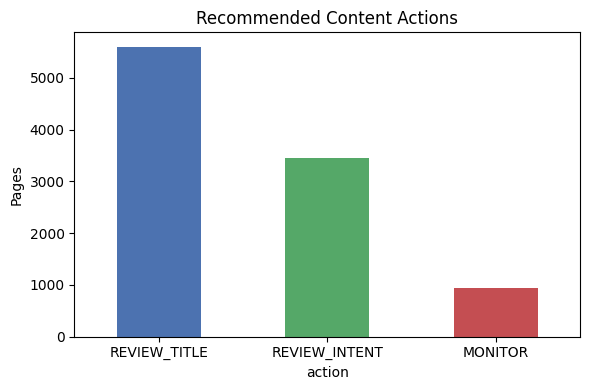

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export CSV
queue.to_csv("work/outputs/action_queue.csv", index=False)
print("Saved queue to work/outputs/action_queue.csv")

# Export Figure
plt.figure(figsize=(6, 4))
queue['action'].value_counts().plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])
plt.title("Recommended Content Actions")
plt.ylabel("Pages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("work/figures/actions_chart.png")
print("Saved chart to work/figures/actions_chart.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.